# Read distance from the 3′ end of single-isoform genes

For every read that maps to a gene with exactly one annotated isoform we
calculate how far the read start is from the gene's 3′ end, measured **only
over exonic bases** (intronic regions are excluded from the count).

## Strand-aware distance formula

Because `pysam` always reports the leftmost (`reference_start`, 0-based) and
one-past-rightmost (`reference_end`, 0-based exclusive / 1-based inclusive)
genomic coordinates regardless of strand, we convert to 1-based coordinates
and choose the appropriate read anchor per strand:

| Strand | 3′ end of gene | Read anchor (1-based) | Distance formula |
|--------|----------------|-----------------------|------------------|
| `+`    | `gene_end`     | `read.reference_start + 1` | `(gene_end − read_pos + 1) − intronic_bases(read_pos, gene_end)` |
| `−`    | `gene_start`   | `read.reference_end`       | `(read_pos − gene_start + 1) − intronic_bases(gene_start, read_pos)` |

All genomic coordinates are 1-based and inclusive (GTF convention).

In [2]:
import os
import re
import pysam
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

## 1. Paths — adjust as needed

In [39]:
out_dir = "/tmp/Mazutislab-out/Ignas/RT_comparison/results"
single_isoform_genes_path = os.path.join(out_dir, "filter_single_isoform_genes/single_isoform_genes.txt")

# GTF annotation file used by the Snakemake rule
gtf_path = "/home/simonasj/references/genome/GRCh38_Ensembl_107/human/gencode.v41.primary_assembly.annotation.gtf.filtered"

# One BAM file per sample (output of the star_mapping rule)
samples = ["25_SSCV_KG_05_S5", "25_SSCV_KG_06_S6"]
# bam_paths = {
#     s: f"{out_dir}/star_mapping/{s}/{s}_Aligned.sortedByCoord.out.bam" for s in samples
# }
bam_paths = {s: f"/tmp/Mazutislab-out/Karolis/Samples/260409_VH02338_14_AAF2KJHHV/260409_VH02338_14_AAF2KJHHV_out/25_SSCV_KG/starsolo/{s}_trimmed/{s}_trimmed_Aligned.sortedByCoord.out.bam" for s in samples}

## 2. Load single-isoform gene list

In [4]:
# Maps gene_id -> transcript_id for all genes with exactly one isoform.
# Also builds gene_id -> gene_name for convenience.
gene_id_to_transcript = {}
gene_id_to_name = {}

with open(single_isoform_genes_path) as fh:
    for line in fh:
        parts = line.strip().split(" ")
        gene_id, gene_name, transcript_id = parts[0], parts[1], parts[2]
        gene_id_to_transcript[gene_id] = transcript_id
        gene_id_to_name[gene_id] = gene_name

print(f"Loaded {len(gene_id_to_transcript):,} single-isoform genes.")

Loaded 15,114 single-isoform genes.


## 3. Build per-gene coordinate dictionary from the GTF

For each single-isoform gene we store:
- `strand` — `'+'` or `'-'`
- `gene_start`, `gene_end` — gene-level 1-based coordinates from the GTF `gene` feature
- `exon_coords` — sorted list of `(start, end)` 1-based tuples for the single transcript's exons
- `intron_coords` — derived from consecutive exon pairs

In [13]:
# Initialise entries for every gene we care about.
gene_info = {
    gene_id: {
        "transcript_id": transcript_id,
        "strand": None,
        "gene_start": None,
        "gene_end": None,
        "exon_coords": [],
        "intron_coords": [],
    }
    for gene_id, transcript_id in gene_id_to_transcript.items()
}

with open(gtf_path) as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 9:
            continue

        feature_type = fields[2]
        if feature_type not in ("gene", "exon"):
            continue

        attr = fields[8]
        m = re.search(r'gene_id "([^"]+)"', attr)
        if not m:
            continue
        gene_id = m.group(1)

        if gene_id not in gene_info:
            continue

        start = int(fields[3])   # 1-based inclusive
        end = int(fields[4])     # 1-based inclusive
        strand = fields[6]

        if feature_type == "gene":
            gene_info[gene_id]["strand"] = strand
            gene_info[gene_id]["gene_start"] = start
            gene_info[gene_id]["gene_end"] = end

        elif feature_type == "exon":
            # Only collect exons belonging to the single isoform of this gene.
            m_t = re.search(r'transcript_id "([^"]+)"', attr)
            if m_t and m_t.group(1) == gene_info[gene_id]["transcript_id"]:
                gene_info[gene_id]["exon_coords"].append((start, end))

# Sort exons by start coordinate and derive intron intervals.
for gene_id, info in gene_info.items():
    exons = sorted(info["exon_coords"], key=lambda x: x[0])
    info["exon_coords"] = exons
    introns = []
    for i in range(1, len(exons)):
        intron_start = exons[i - 1][1] + 1
        intron_end = exons[i][0] - 1
        if intron_end >= intron_start:   # sanity check
            introns.append((intron_start, intron_end))
    info["intron_coords"] = introns
    exon_lengths = [end - start + 1 for start, end in exons]
    info["gene_length"] = sum(exon_lengths)

# Report how many genes were fully annotated (have gene-level coordinates).
n_complete = sum(1 for info in gene_info.values() if info["gene_start"] is not None)
print(f"Gene info built for {n_complete:,} / {len(gene_info):,} single-isoform genes.")

Gene info built for 15,114 / 15,114 single-isoform genes.


### Quick sanity check on a single gene

In [6]:
example_gene = next(iter(gene_info))
print(f"Gene: {example_gene}  ({gene_id_to_name[example_gene]})")
info = gene_info[example_gene]
print(f"  strand     : {info['strand']}")
print(f"  gene_start : {info['gene_start']}")
print(f"  gene_end   : {info['gene_end']}")
print(f"  exon_coords: {info['exon_coords']}")
print(f"  intron_coords: {info['intron_coords']}")

Gene: GRCh38_ENSG00000001561  (GRCh38_ENPP4)
  strand     : +
  gene_start : 46129989
  gene_end   : 46146688
  exon_coords: [(46129989, 46130189), (46139551, 46140409), (46141052, 46141222), (46143276, 46146688)]
  intron_coords: [(46130190, 46139550), (46140410, 46141051), (46141223, 46143275)]


## 4. Helper functions

In [7]:
def intronic_bases_between(intron_coords, pos1, pos2):
    """
    Count intronic bases that fall within the closed genomic interval [pos1, pos2]
    (1-based, inclusive). Both pos1 and pos2 are assumed to be within the gene.
    """
    count = 0
    for intron_start, intron_end in intron_coords:
        overlap_start = max(intron_start, pos1)
        overlap_end = min(intron_end, pos2)
        if overlap_end >= overlap_start:
            count += overlap_end - overlap_start + 1
    return count


def distance_from_3prime(read, info):
    """
    Compute the exonic distance (in bases) from the read's transcript-start
    position to the gene's 3′ end, excluding intronic bases.

    Parameters
    ----------
    read : pysam.AlignedSegment
    info : dict   — entry from gene_info for the gene the read maps to

    Returns
    -------
    int or None
        Distance in exonic bases, or None if the read anchor falls outside
        the gene boundaries.
    """
    strand = info["strand"]
    gene_start = info["gene_start"]
    gene_end = info["gene_end"]
    intron_coords = info["intron_coords"]

    if strand == "+":
        # 3′ end is at gene_end (highest coordinate).
        # Read anchor: leftmost mapped base, converted to 1-based.
        read_pos = read.reference_start + 1
        if read_pos < gene_start or read_pos > gene_end:
            return None
        n_intronic = intronic_bases_between(intron_coords, read_pos, gene_end)
        return (gene_end - read_pos + 1) - n_intronic

    else:  # strand == "-"
        # 3′ end is at gene_start (lowest coordinate).
        # Read anchor: rightmost mapped base.
        # pysam reference_end is 0-based exclusive, which equals the 1-based
        # inclusive end of the last aligned base.
        read_pos = read.reference_end
        if read_pos < gene_start or read_pos > gene_end:
            return None
        n_intronic = intronic_bases_between(intron_coords, gene_start, read_pos)
        return (read_pos - gene_start + 1) - n_intronic

## 5. Iterate over BAM files and compute distances

In [41]:
# For each sample, collect the exonic distances from the 3′ end.
distances_per_sample = {}
gene_lengths_per_sample = {}
genes_per_sample = {}

for sample, bam_path in bam_paths.items():
    print(f"\nProcessing {sample} ...")
    bam = pysam.AlignmentFile(bam_path, "rb")

    distances = []
    gene_lengths = []
    genes = []
    n_total = 0
    n_not_single_isoform = 0

    for read in tqdm.tqdm(bam.fetch()):
        # Skip unmapped, secondary, supplementary reads.
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        n_total += 1
        gene_id = read.get_tag("GX")
        # Skip reads not assigned to a single-isoform gene.
        if gene_id not in gene_info:
            n_not_single_isoform += 1
            continue

        dist = distance_from_3prime(read, gene_info[gene_id])
        length = gene_info[gene_id]["gene_length"]

        distances.append(dist)
        genes.append(gene_id)
        gene_lengths.append(length)

    bam.close()
    distances_per_sample[sample] = np.array(distances)
    gene_lengths_per_sample[sample] = np.array(gene_lengths)
    genes_per_sample[sample] = genes

    print(f"  total primary reads         : {n_total:,}")
    print(f"  not in single-isoform genes : {n_not_single_isoform:,}")
    print(f"  reads used in statistic     : {len(distances):,}")


Processing 25_SSCV_KG_05_S5 ...


0it [00:00, ?it/s]

80005300it [04:03, 328813.43it/s]


  total primary reads         : 57,189,012
  not in single-isoform genes : 54,688,342
  reads used in statistic     : 2,500,670

Processing 25_SSCV_KG_06_S6 ...


54345622it [02:46, 327181.01it/s]


  total primary reads         : 38,828,725
  not in single-isoform genes : 36,917,798
  reads used in statistic     : 1,910,927


## 6. Plot the distribution of distances from the 3′ end

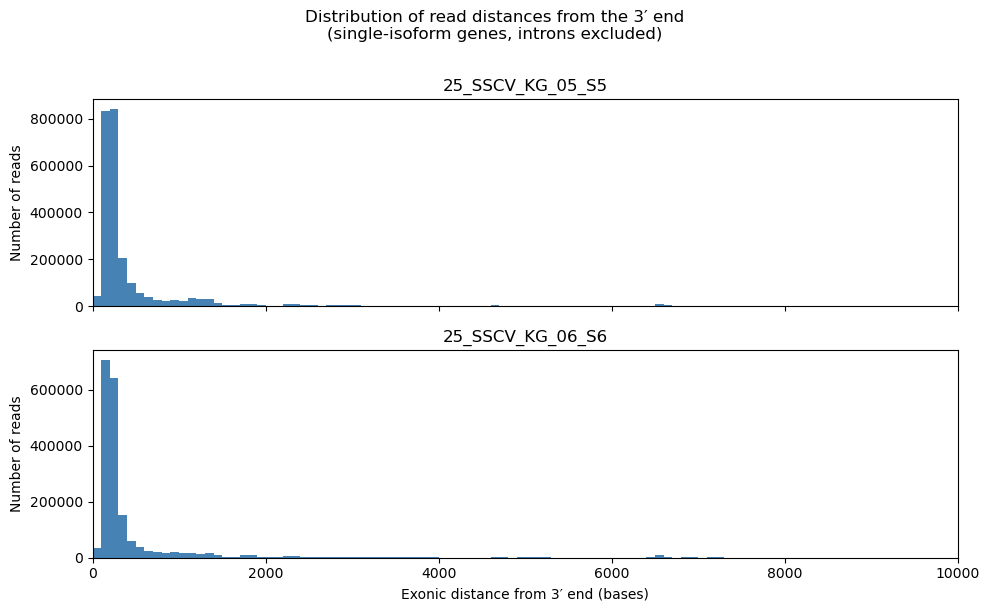

In [42]:
fig, axes = plt.subplots(len(samples), 1, figsize=(10, 3 * len(samples)), sharex=True)

max_dist = max(
    (d.max() for d in distances_per_sample.values() if len(d) > 0),
    default=5000,
)
bin_edges = np.arange(0, min(max_dist + 100, 10001), 100)

for ax, sample in zip(axes, samples):
    dists = distances_per_sample.get(sample, np.array([]))
    ax.hist(dists, bins=bin_edges, color="steelblue", edgecolor="none")
    ax.set_title(sample)
    ax.set_ylabel("Number of reads")
    ax.set_xlim(0, bin_edges[-1])

axes[-1].set_xlabel("Exonic distance from 3′ end (bases)")
fig.suptitle(
    "Distribution of read distances from the 3′ end\n"
    "(single-isoform genes, introns excluded)",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [43]:
min_gene_length = 1000
filtered_distances_per_sample = {}
filtered_gene_lengths_per_sample = {}
normalized_distances_per_sample = {}
filtered_genes_per_sample = {}
for sample in samples:
    mask = gene_lengths_per_sample[sample] >= min_gene_length
    filtered_distances_per_sample[sample] = distances_per_sample[sample][mask]
    filtered_gene_lengths_per_sample[sample] = gene_lengths_per_sample[sample][mask]
    filtered_genes_per_sample[sample] = np.array(genes_per_sample[sample])[mask]
    normalized_distances_per_sample[sample] = filtered_distances_per_sample[sample] / filtered_gene_lengths_per_sample[sample]

In [23]:
normalized_distances_per_sample['25_SSCV_KG_05_S5']

array([0.97101449, 0.97101449, 0.97101449, ..., 0.15114236, 0.80896572,
       0.92415499], shape=(140447,))

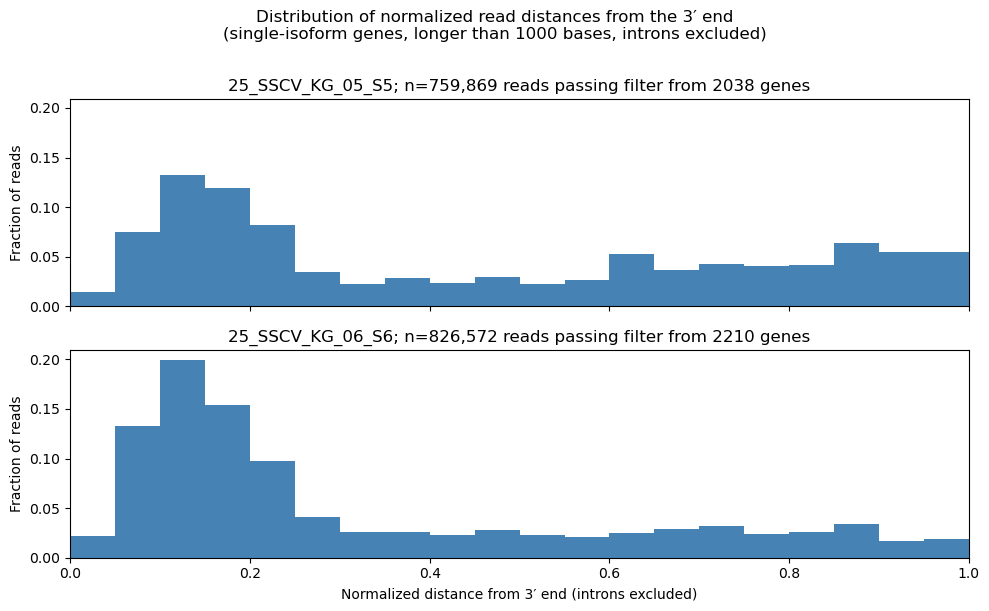

In [44]:
#plot histigrams of normalized distances
normalize_histogram = True
fig, axes = plt.subplots(len(samples), 1, figsize=(10, 3 * len(samples)), sharex=True, sharey=True)
max_dist = max(
    (d.max() for d in normalized_distances_per_sample.values() if len(d) > 0),
    default=1.0,
)
bin_edges = np.arange(0, min(max_dist + 0.01, 1.01), 0.05)
for ax, sample in zip(axes, samples):
    dists = normalized_distances_per_sample.get(sample, np.array([]))
    if normalize_histogram:
        weights = np.ones_like(dists) / len(dists) if len(dists) > 0 else None
        ax.hist(dists, bins=bin_edges, color="steelblue", edgecolor="none", weights=weights)
        ax.set_ylabel("Fraction of reads")
    else:
        ax.hist(dists, bins=bin_edges, color="steelblue", edgecolor="none")
        ax.set_ylabel("Number of reads")
    ax.set_title(f"{sample}; n={len(dists):,} reads passing filter from {len(set(filtered_genes_per_sample[sample]))} genes")
    ax.set_xlim(0, bin_edges[-1])
axes[-1].set_xlabel("Normalized distance from 3′ end (introns excluded)")
fig.suptitle(
    "Distribution of normalized read distances from the 3′ end\n"
    f"(single-isoform genes, longer than {min_gene_length} bases, introns excluded)",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [12]:
# Summary statistics per sample
print(f"{'Sample':<30} {'N reads':>10} {'Median dist':>12} {'Mean dist':>10}")
print("-" * 65)
for sample in samples:
    dists = distances_per_sample.get(sample, np.array([]))
    if len(dists) == 0:
        print(f"{sample:<30} {'0':>10} {'NA':>12} {'NA':>10}")
    else:
        print(
            f"{sample:<30} {len(dists):>10,} "
            f"{np.median(dists):>12.1f} {np.mean(dists):>10.1f}"
        )

Sample                            N reads  Median dist  Mean dist
-----------------------------------------------------------------
25_SSCV_KG_05_S5                  355,349        261.0      678.9
25_SSCV_KG_06_S6                  178,656        229.0      609.0
